# Teste Interativo da Classe FlightClusterer

Notebook de validação da classe `FlightClusterer` (clusterização de aeroportos por perfil de atrasos).

Pipeline testado:
1. Importação e instanciação
2. Carregamento dos dados
3. Agregação de features por aeroporto
4. Pré-processamento (padronização)
5. Determinação do melhor k (Elbow + Silhouette)
6. KMeans final
7. Resumo dos clusters e top aeroportos
8. PCA — variância, projeção 2D e loadings
9. Silhouette plot detalhado

In [1]:
import sys
from pathlib import Path

# Adiciona o diretório raiz do projeto para permitir importar a classe do módulo notebooks
sys.path.append(str(Path(".").resolve().parent))

from notebooks.clusterizacao import FlightClusterer

In [2]:
# Inicializa o clusterizador.
# min_voos=500 → mesmo filtro do notebook original (evita ruído estatístico).
# k_range padrão é range(2, 11), k_final=None deixa a classe escolher pelo Silhouette.
clusterer = FlightClusterer(
    input_path="../data/processed/flights_model.parquet",
    min_voos=500,
)

In [3]:
# 1. Carregar os dados brutos
df = clusterer.load_data()
df.head(3)

Carregando dados de: ../data/processed/flights_model.parquet ...
Existe? True
Shape: (5714008, 34)


YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,is_delayed,scheduled_departure_hour,periodo_dia
i64,i64,i64,i64,str,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,i8,i64,str
2015,1,1,4,"""AS""",98,"""N407AS""","""ANC""","""SEA""",5,2354,-11,21,15,205,194,169,1448,404,4,430,408,-22,0,0,null,null,null,null,null,null,0,0,"""madrugada"""
2015,1,1,4,"""AA""",2336,"""N3KUAA""","""LAX""","""PBI""",10,2,-8,12,14,280,279,263,2330,737,4,750,741,-9,0,0,null,null,null,null,null,null,0,0,"""madrugada"""
2015,1,1,4,"""US""",840,"""N171US""","""SFO""","""CLT""",20,18,-2,16,34,286,293,266,2296,800,11,806,811,5,0,0,null,null,null,null,null,null,1,0,"""madrugada"""


In [4]:
# 2. Agregar features por aeroporto de origem
airport_features = clusterer.aggregate_by_airport()
airport_features.head()


=== Agregando features por aeroporto (mín. 500 voos) ===
Aeroportos com >= 500 voos: 403


ORIGIN_AIRPORT,qtd_voos,media_arrival_delay,mediana_arrival_delay,std_arrival_delay,taxa_atraso,taxa_atraso_grave,media_departure_delay,distancia_media,tempo_voo_medio,n_airlines,n_destinos,pct_manha,pct_tarde,pct_noite
str,u32,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,f64,f64,f64
"""ATL""",343506,3.046774,-6.0,34.867115,0.33441,0.15812,9.290225,640.193854,121.246476,11,168,0.321267,0.380107,0.296004
"""ORD""",276554,8.60079,-4.0,43.825811,0.409616,0.233788,14.033679,722.212255,133.230205,12,161,0.349852,0.388763,0.250826
"""DFW""",232647,6.918959,-4.0,38.751554,0.399979,0.209214,11.41489,787.480449,135.286382,11,148,0.343387,0.382408,0.266717
"""DEN""",193402,7.187909,-3.0,37.638247,0.417555,0.21612,11.756843,876.490998,141.822137,11,139,0.391547,0.32266,0.268803
"""LAX""",192003,5.723421,-3.0,37.247938,0.414895,0.201257,10.624865,1252.075514,184.453571,13,80,0.384275,0.336953,0.247991


In [5]:
# 3. Pré-processamento: nulos + StandardScaler
X_scaled = clusterer.preprocess_features()
print(f"\nShape final: {X_scaled.shape}")


=== Pré-processamento ===
Nulos por feature:
media_arrival_delay      0
mediana_arrival_delay    0
std_arrival_delay        0
taxa_atraso              0
taxa_atraso_grave        0
media_departure_delay    0
distancia_media          0
tempo_voo_medio          0
n_airlines               0
n_destinos               0
pct_manha                0
pct_tarde                0
pct_noite                0
dtype: int64

Shape para clusterização: (403, 13)

Shape final: (403, 13)


In [6]:
# 4. Determinar melhor k via Elbow + Silhouette
best_k = clusterer.find_best_k()


=== Buscando melhor k ===
k=2  inertia=4089.4  silhouette=0.2088
k=3  inertia=3336.4  silhouette=0.2193
k=4  inertia=3064.4  silhouette=0.1792
k=5  inertia=2913.9  silhouette=0.1815
k=6  inertia=2691.8  silhouette=0.1551
k=7  inertia=2571.0  silhouette=0.1585
k=8  inertia=2428.0  silhouette=0.1628
k=9  inertia=2326.3  silhouette=0.1626
k=10  inertia=2211.9  silhouette=0.1518

Melhor k pelo Silhouette: 3


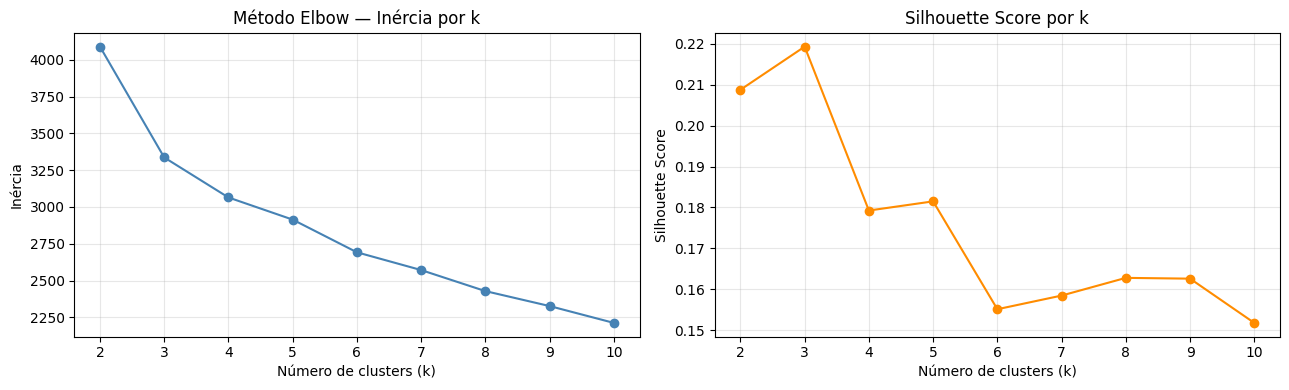

In [7]:
# Gráfico Elbow + Silhouette
clusterer.plot_k_selection()

In [8]:
# 5. KMeans final com o k escolhido
clusterer.fit_kmeans()


=== Treinando KMeans final com k=3 ===
Distribuição de aeroportos por cluster:
cluster
0    157
1    139
2    107
Name: count, dtype: int64


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [9]:
# 6. Resumo do perfil médio de cada cluster
perfil = clusterer.summarize_clusters()
perfil


=== Perfil médio de cada cluster ===
         taxa_atraso  taxa_atraso_grave  media_arrival_delay  \
cluster                                                        
0               0.37               0.18                 6.49   
1               0.27               0.12                -0.42   
2               0.34               0.15                 2.32   

         media_departure_delay  std_arrival_delay  distancia_media  \
cluster                                                              
0                         8.12              46.22           413.76   
1                         3.50              37.48           487.07   
2                         7.39              36.39           914.54   

         n_destinos  qtd_voos  
cluster                        
0              5.83   3919.35  
1             10.17   2461.94  
2             53.52  44096.01  


,taxa_atraso,taxa_atraso_grave,media_arrival_delay,media_departure_delay,std_arrival_delay,distancia_media,n_destinos,qtd_voos
cluster,,,,,,,,
0,0.37,0.18,6.49,8.12,46.22,413.76,5.83,3919.35
1,0.27,0.12,-0.42,3.50,37.48,487.07,10.17,2461.94
2,0.34,0.15,2.32,7.39,36.39,914.54,53.52,44096.01


In [10]:
# Top 8 aeroportos (por volume) em cada cluster
clusterer.show_top_airports_per_cluster(top_n=8)


=== Top 8 aeroportos por volume em cada cluster ===
Cluster 0 (157 aeroportos | taxa_atraso média=36.78%): ['DAL', 'ONT', 'OKC', 'RIC', 'MEM', 'TUL', 'RNO', 'BHM']
Cluster 1 (139 aeroportos | taxa_atraso média=27.46%): ['PIT', 'BUR', 'BUF', 'TUS', 'GRR', 'GEG', 'MSN', '14869']
Cluster 2 (107 aeroportos | taxa_atraso média=34.13%): ['ATL', 'ORD', 'DFW', 'DEN', 'LAX', 'PHX', 'SFO', 'IAH']


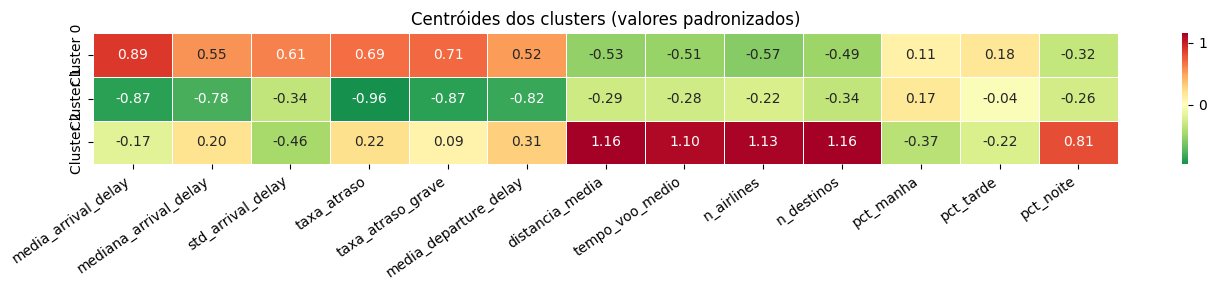

In [11]:
# Heatmap dos centróides (valores padronizados)
clusterer.plot_centroids_heatmap()

## PCA — Redução de dimensionalidade e visualização

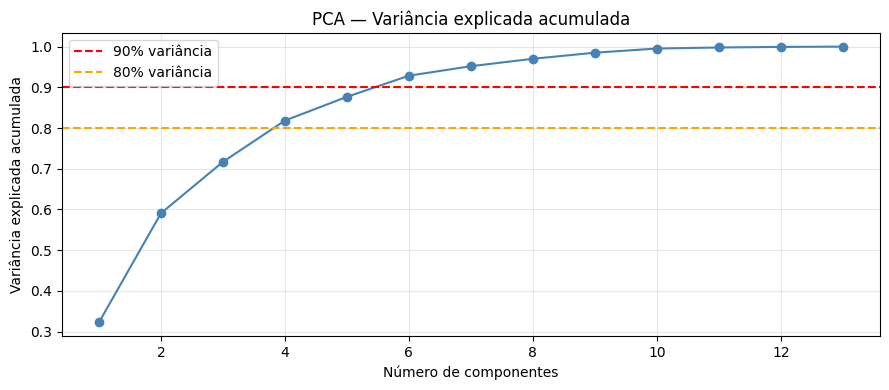

Componentes necessários para 90% da variância: 6


In [12]:
# 7. PCA completo + variância explicada acumulada
clusterer.fit_pca_full()
clusterer.plot_pca_variance()

PC1 explica 32.3% | PC2 explica 26.8% | Total: 59.1%


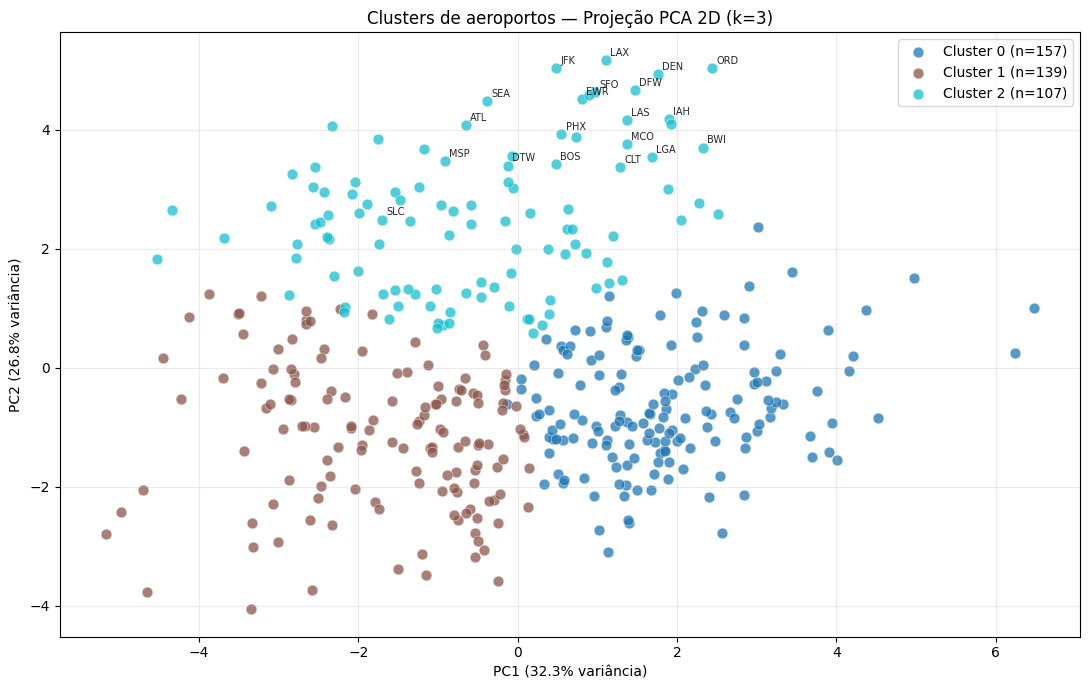

In [13]:
# 8. Projeção 2D dos clusters
clusterer.fit_pca_2d()
clusterer.plot_pca_clusters()

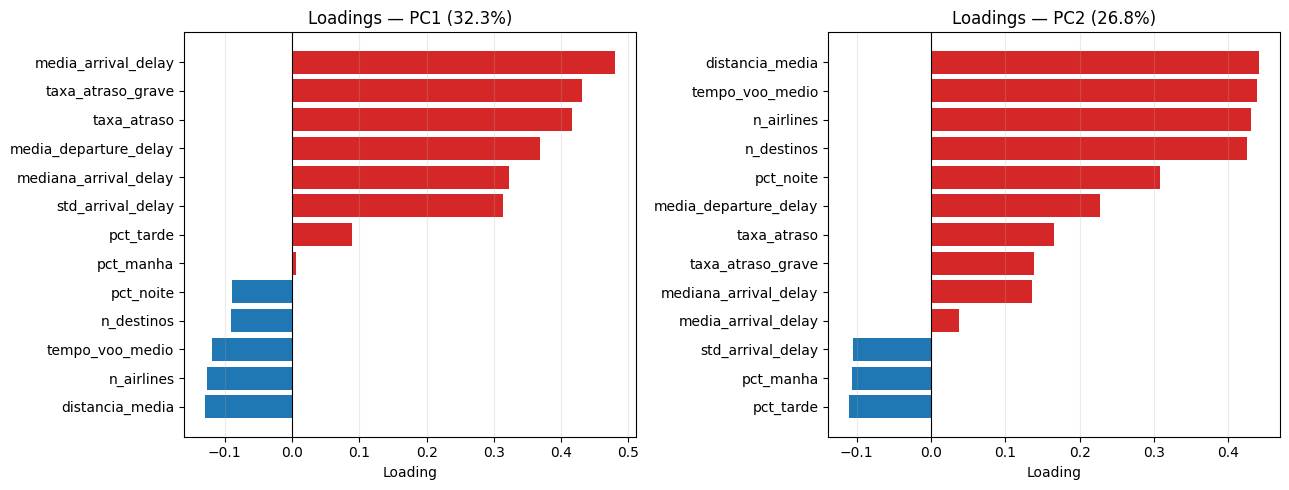

In [14]:
# 9. Loadings — o que cada componente PCA captura?
clusterer.plot_pca_loadings()

## Silhouette plot detalhado por cluster

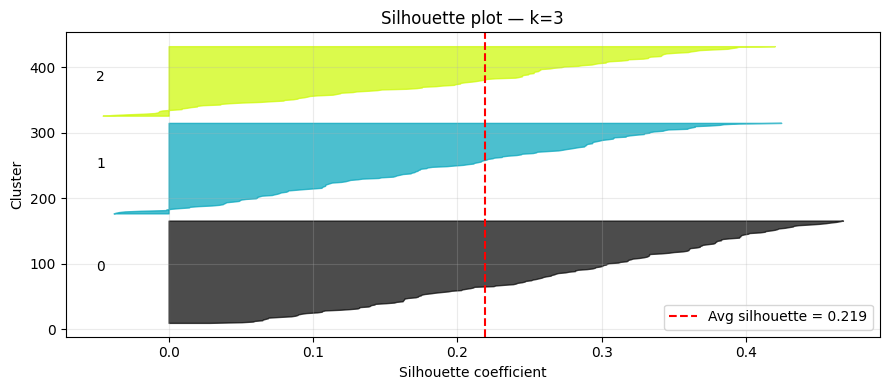

In [15]:
# 10. Silhouette plot — visualizar qualidade da separação dentro de cada cluster
clusterer.plot_silhouette()

## Alternativa: pipeline completo com `run_all`

Se quiser executar tudo de uma vez em vez de passo a passo:

In [16]:
# Roda o pipeline inteiro de uma vez
# clusterer_full = FlightClusterer(
#     input_path="../data/processed/flights_model.parquet",
# )
# clusterer_full.run_all(show_plots=True)

## Forçar um k específico (opcional)

Se você quiser experimentar com um k diferente do escolhido pelo Silhouette, passe `k_final` no construtor:

In [ ]:
# Exemplo: forçar k=4 em vez do k_final=3 escolhido automaticamente
# clusterer_k4 = FlightClusterer(
#     input_path="../data/processed/flights_model.parquet",
#     k_final=4,
# )
# clusterer_k4.run_all(show_plots=True)